# Modeling dengan Decision Tree dan Random Forest

Notebook ini dibuat untuk melakukan pemodelan data menggunakan algoritma Decision Tree dan Random Forest dengan data `dataset_cleaned_lengkap.csv`. Karena dataset ini masih mengandung variabel mentah yang tidak sesuai untuk dimasukkan langsung ke dalam model (seperti teks kategori), kita menyertakan tahapan preprocessing (Scaling dan Encoding) menggunakan `Pipeline` dari scikit-learn agar alur pemrosesan lebih kokoh dan konsisten dari tahap training hingga deployment.

In [18]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\ThinkPad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Memuat Data

In [20]:
# Load dataset
df = pd.read_csv('data/dataset_cleaned_lengkap.csv')
df.head()

,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_desa_kelurahan,kemendagri_kode_kecamatan,...,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,nama_unit_bank_sampah,alamat_bank_sampah,tahun,alamat_missing_flag,volume_sampah_kg,kapasitas_tps_kg,status_tps,status_tps_encoded
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210002,CICADAS,32.73.14,...,32.73.14.1003,CICADAS,BANK SAMPAH TERATAI INDAH,RW 10,2019,0,202.0,502.0,tidak penuh,0
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210002,CICADAS,32.73.14,...,32.73.14.1003,CICADAS,BANK SAMPAH MANDIRI,RW 11,2019,0,535.0,502.0,penuh,1
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,...,32.73.14.1002,CIKUTRA,BANK SAMPAH LESTARI HIJAU,RW 04,2019,0,370.0,835.0,tidak penuh,0
3,4,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,...,32.73.14.1002,CIKUTRA,BANK SAMPAH LESTARI HIJAU,RW 07,2019,0,206.0,835.0,tidak penuh,0
4,5,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,...,32.73.14.1002,CIKUTRA,BANK SAMPAH DAHLIA,RW 08,2019,0,171.0,835.0,tidak penuh,0


## 1b. Matrix Koefisien Korelasi Fitur Numerik

Sebelum masuk ke tahap pemodelan, kita lihat hubungan antar fitur numerik menggunakan **matriks koefisien korelasi (Pearson)**. Visualisasi ini membantu mengidentifikasi fitur yang saling berkorelasi kuat (potensi multikolinearitas) serta fitur yang paling berhubungan dengan target `status_tps_encoded`.

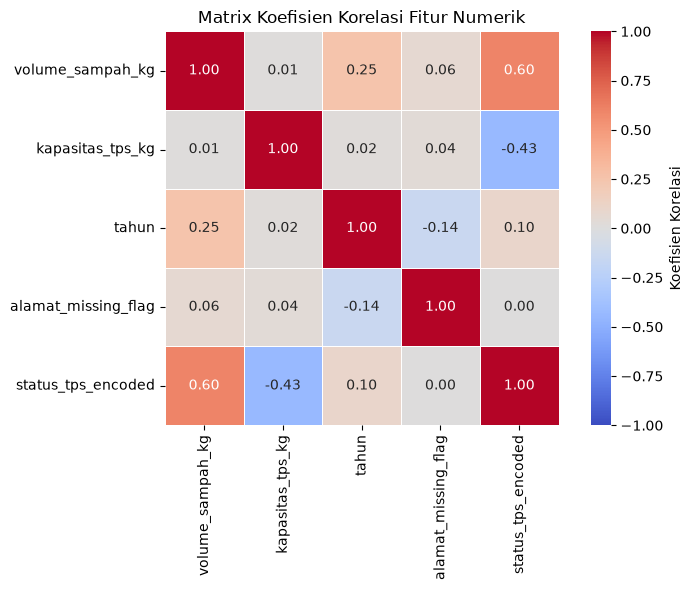

In [21]:
# Memilih fitur numerik (termasuk target) untuk analisis korelasi
fitur_numerik = ['volume_sampah_kg', 'kapasitas_tps_kg', 'tahun',
                 'alamat_missing_flag', 'status_tps_encoded']

# Menghitung matriks koefisien korelasi (Pearson)
corr_matrix = df[fitur_numerik].corr()

# Visualisasi sebagai heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Matrix Koefisien Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

## 2. Preprocessing & Pemisahan Fitur

In [22]:
# Memilih fitur yang relevan untuk model
fitur_relevan = [
    'volume_sampah_kg', 'kapasitas_tps_kg', 'tahun', 'alamat_missing_flag',
    'bps_desa_kelurahan', 'nama_unit_bank_sampah'
]

X = df[fitur_relevan]
y = df['status_tps_encoded']

# Mendefinisikan kolom numerik dan kategorik
num_features = ['volume_sampah_kg', 'kapasitas_tps_kg', 'tahun', 'alamat_missing_flag']
cat_features = ['bps_desa_kelurahan', 'nama_unit_bank_sampah']

# Membuat Preprocessor (StandardScaler & OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Membagi data menjadi training set dan testing set (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

Dimensi X_train: (146, 6)
Dimensi X_test: (37, 6)


## 3. Modeling: Decision Tree dengan Pipeline

=== Performa Decision Tree ===
Akurasi: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         6

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



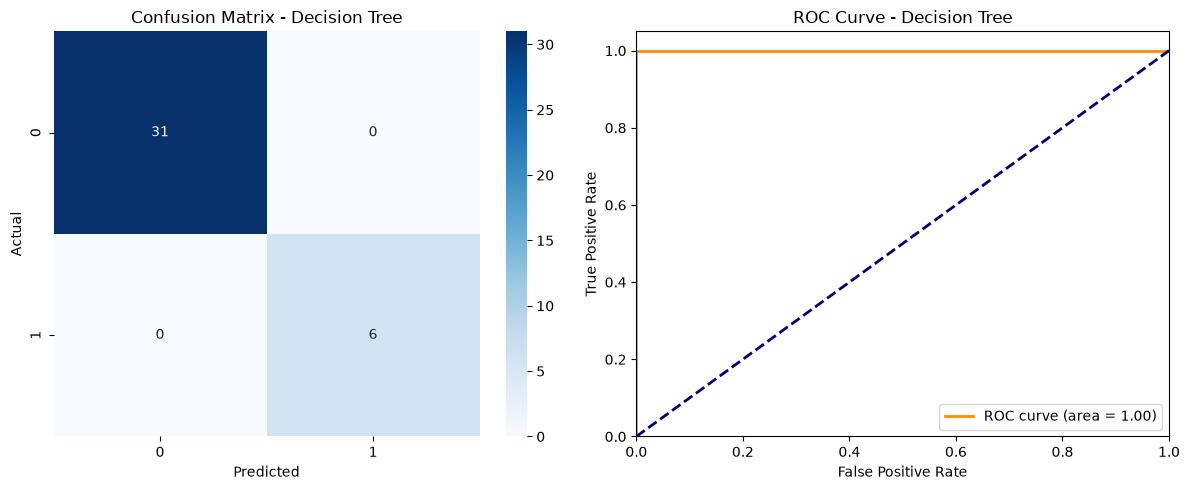

In [23]:
# Membangun Pipeline untuk Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Pelatihan Model
dt_pipeline.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

# Evaluasi model
print("=== Performa Decision Tree ===")
print("Akurasi:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Visualisasi Confusion Matrix dan ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.subplot(1, 2, 2)
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_dt)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 4. Modeling: Random Forest dengan Pipeline

=== Performa Random Forest ===
Akurasi: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         6

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



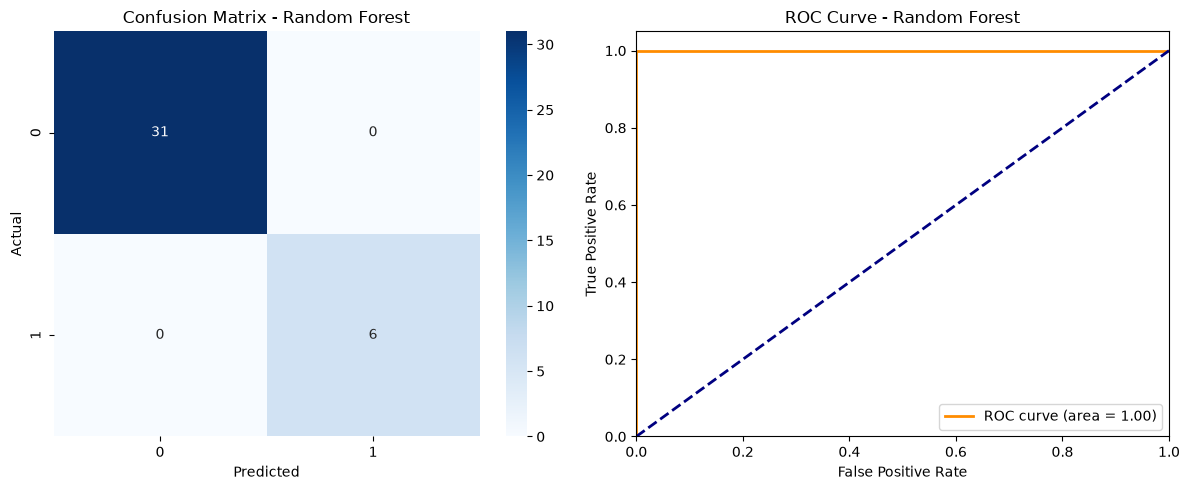

In [24]:
# Membangun Pipeline untuk Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

# Pelatihan Model
rf_pipeline.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluasi model
print("=== Performa Random Forest ===")
print("Akurasi:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix dan ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.subplot(1, 2, 2)
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 5. Analisis Fitur Penting (Feature Importance)
Mengekstrak kembali nama fitur dari `OneHotEncoder` di dalam Pipeline untuk memvisualisasikan fitur mana yang paling berpengaruh di model Random Forest.

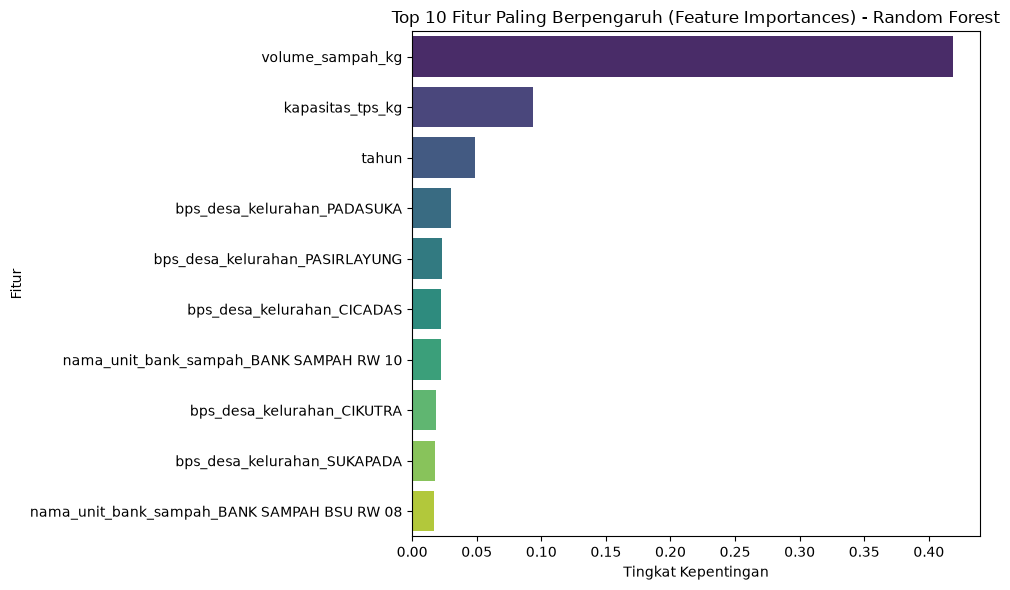

In [25]:
# Mendapatkan nama fitur hasil transformasi dari preprocessor
cat_features_encoded = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(cat_features_encoded)

# Mendapatkan tingkat kepentingan dari Random Forest
feature_importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Menyusun ke dalam DataFrame
fi_df = pd.DataFrame({'Fitur': all_feature_names, 'Tingkat Kepentingan': feature_importances})
fi_df = fi_df.sort_values(by='Tingkat Kepentingan', ascending=False)

# Visualisasi Top 10 Fitur
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=fi_df.head(10), palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importances) - Random Forest')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## 6. Perbandingan Performa Model

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0


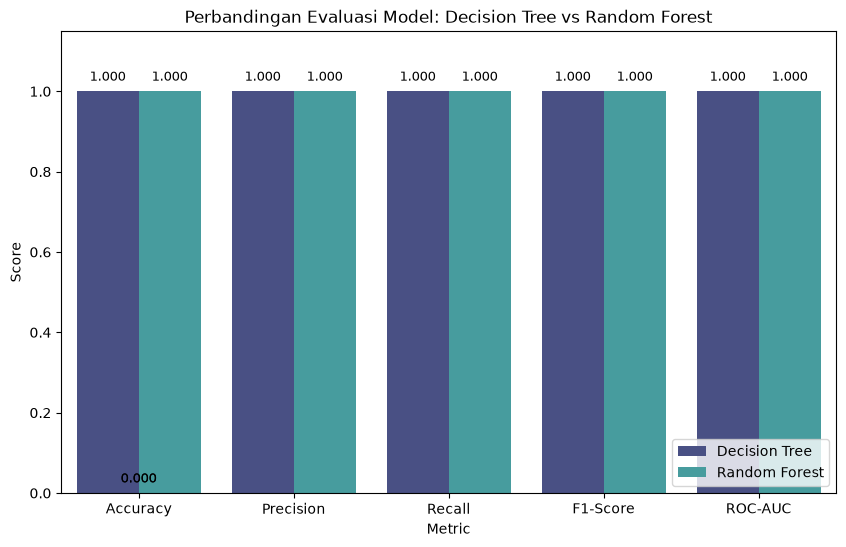

In [26]:
# Mengumpulkan metrik evaluasi ke dalam DataFrame
metrics_data = {
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    'Recall': [recall_score(y_test, y_pred_dt, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    'F1-Score': [f1_score(y_test, y_pred_dt, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')],
    'ROC-AUC': [roc_auc_dt, roc_auc_rf]
}

comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

# Visualisasi Perbandingan Metrik (Bar Plot)
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='mako')
plt.title('Perbandingan Evaluasi Model: Decision Tree vs Random Forest')
plt.ylim(0, 1.15)

# Tambahkan anotasi nilai di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

plt.legend(loc='lower right')
plt.show()

## 7. Menyimpan Pipeline untuk Deployment Streamlit

In [27]:
import joblib

# Menyimpan Pipeline Random Forest
joblib.dump(rf_pipeline, 'rf_pipeline.pkl')

print("Pipeline berhasil disimpan dengan nama 'rf_pipeline.pkl'")

Pipeline berhasil disimpan dengan nama 'rf_pipeline.pkl'
